In [ ]:
# === [TFM_newcodes] redireccion de figuras a la carpeta ./figures/ ===
# Celda anadida automaticamente: cualquier figura guardada con un nombre
# de fichero simple (sin carpeta) se guarda dentro de ./figures/.
# Las rutas que ya incluyen una carpeta (p.ej. 'figures/...') se respetan.
import os as _os
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure
_os.makedirs('figures', exist_ok=True)
def _fig_redirect(fname):
    try:
        p = _os.fspath(fname)
    except TypeError:
        return fname  # objeto tipo fichero/buffer: no tocar
    if _os.path.dirname(p) == '':
        p = _os.path.join('figures', p)
    d = _os.path.dirname(p)
    if d:
        _os.makedirs(d, exist_ok=True)
    return p
if not getattr(_plt.savefig, '_tfm_patched', False):
    _orig_plt_savefig = _plt.savefig
    _orig_fig_savefig = _Figure.savefig
    def _plt_savefig(fname, *a, **k):
        return _orig_plt_savefig(_fig_redirect(fname), *a, **k)
    _plt_savefig._tfm_patched = True
    def _fig_savefig(self, fname, *a, **k):
        return _orig_fig_savefig(self, _fig_redirect(fname), *a, **k)
    _plt.savefig = _plt_savefig
    _Figure.savefig = _fig_savefig
savefig = _plt.savefig  # por si se usa savefig(...) directamente


# Temporal Anlaysis of Message distribution

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [41]:
# import datasets
df = pd.read_json("../../Datasets/vagarenfe.json") # Import data from Vaga Renfe groupchat.

## Distribution of messages (Baseline model: 2024)

In [42]:
# Check data structure
print(df.shape)
print(df.columns)
df.head()

(92813, 24)
Index(['id', 'date', 'message', 'reply_to_msg_id', 'views', 'forwards',
       'pinned', 'sender_id', 'sender_username', 'sender_name', 'sender_type',
       'has_media', 'reactions', 'is_forwarded', 'edit_date', 'topic_id',
       'topic_name', 'is_reply', 'fwd_original_date', 'fwd_from_user_id',
       'fwd_from_username', 'fwd_from_channel_id', 'fwd_from_channel_name',
       'fwd_from_name'],
      dtype='object')


,id,date,message,reply_to_msg_id,views,forwards,pinned,sender_id,sender_username,sender_name,...,edit_date,topic_id,topic_name,is_reply,fwd_original_date,fwd_from_user_id,fwd_from_username,fwd_from_channel_id,fwd_from_channel_name,fwd_from_name
0,2,2019-02-08 18:56:18+00:00,Hem activat aquest grup de telegram per autoge...,NaN,NaN,NaN,False,145800528.0,Xirinacs,Xirinacs,...,2023-06-27T07:10:44+00:00,1,General,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2019-02-08 19:04:33+00:00,Benvingut al grup. Gràcies per afegir-te. Pots...,NaN,NaN,NaN,False,145800528.0,Xirinacs,Xirinacs,...,2023-11-15T18:17:55+00:00,1,General,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,2019-02-08 19:08:52+00:00,Gràcies per afegir-vos. Hem de fer viral la pr...,NaN,NaN,NaN,False,145800528.0,Xirinacs,Xirinacs,...,2023-05-12T12:24:10+00:00,1,General,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7,2019-02-08 19:10:00+00:00,Els hashtags a les xarxes socials són: #NoVull...,NaN,NaN,NaN,False,145800528.0,Xirinacs,Xirinacs,...,NaN,1,General,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,2019-02-08 19:16:40+00:00,Hem de sumar a més persones en aquest grup. In...,NaN,NaN,NaN,False,145800528.0,Xirinacs,Xirinacs,...,NaN,1,General,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Convert date to datetime and sort by time
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Total messages: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Total messages: 92813
Date range: 2019-02-08 18:56:18+00:00 to 2026-04-28 15:40:35+00:00


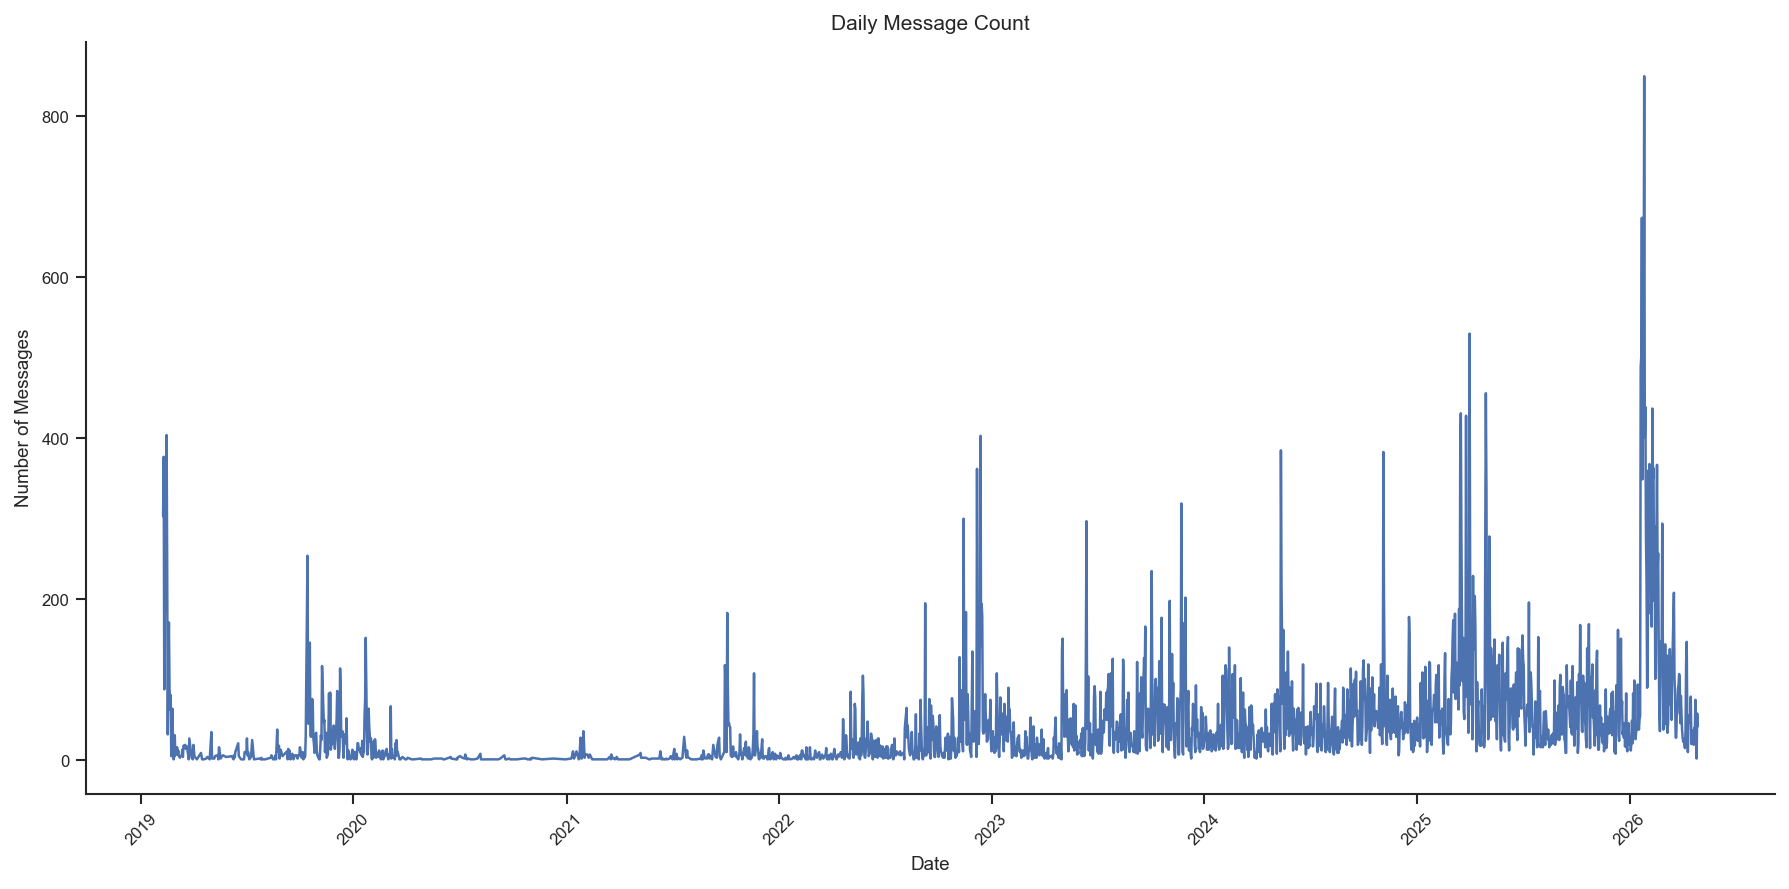

In [44]:
# Plot the distribution of messages over time (daily)
plt.figure(figsize=(12, 6))
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()
daily_counts.plot(kind='line')
plt.title('Daily Message Count')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I talked with Emanuele and I could choose the cutoff using an exponential to see when it starts to decay exponentially. Talk to him to do so, right now I will just use January 1st as the cutoff.

In [45]:
# number of total users in the dataset
total_users = df['sender_id'].nunique()
print(f"Total unique users: {total_users}")

Total unique users: 2016


### Distribution of messages until Jan 1st 2025

Total messages from Jan 1st 2024 until Jan 1st 2025: 17611
Total messages sent in total (until Nov 10th 2025): 92813
Date range: 2024-01-01 04:30:44+00:00 to 2024-12-31 23:33:33+00:00


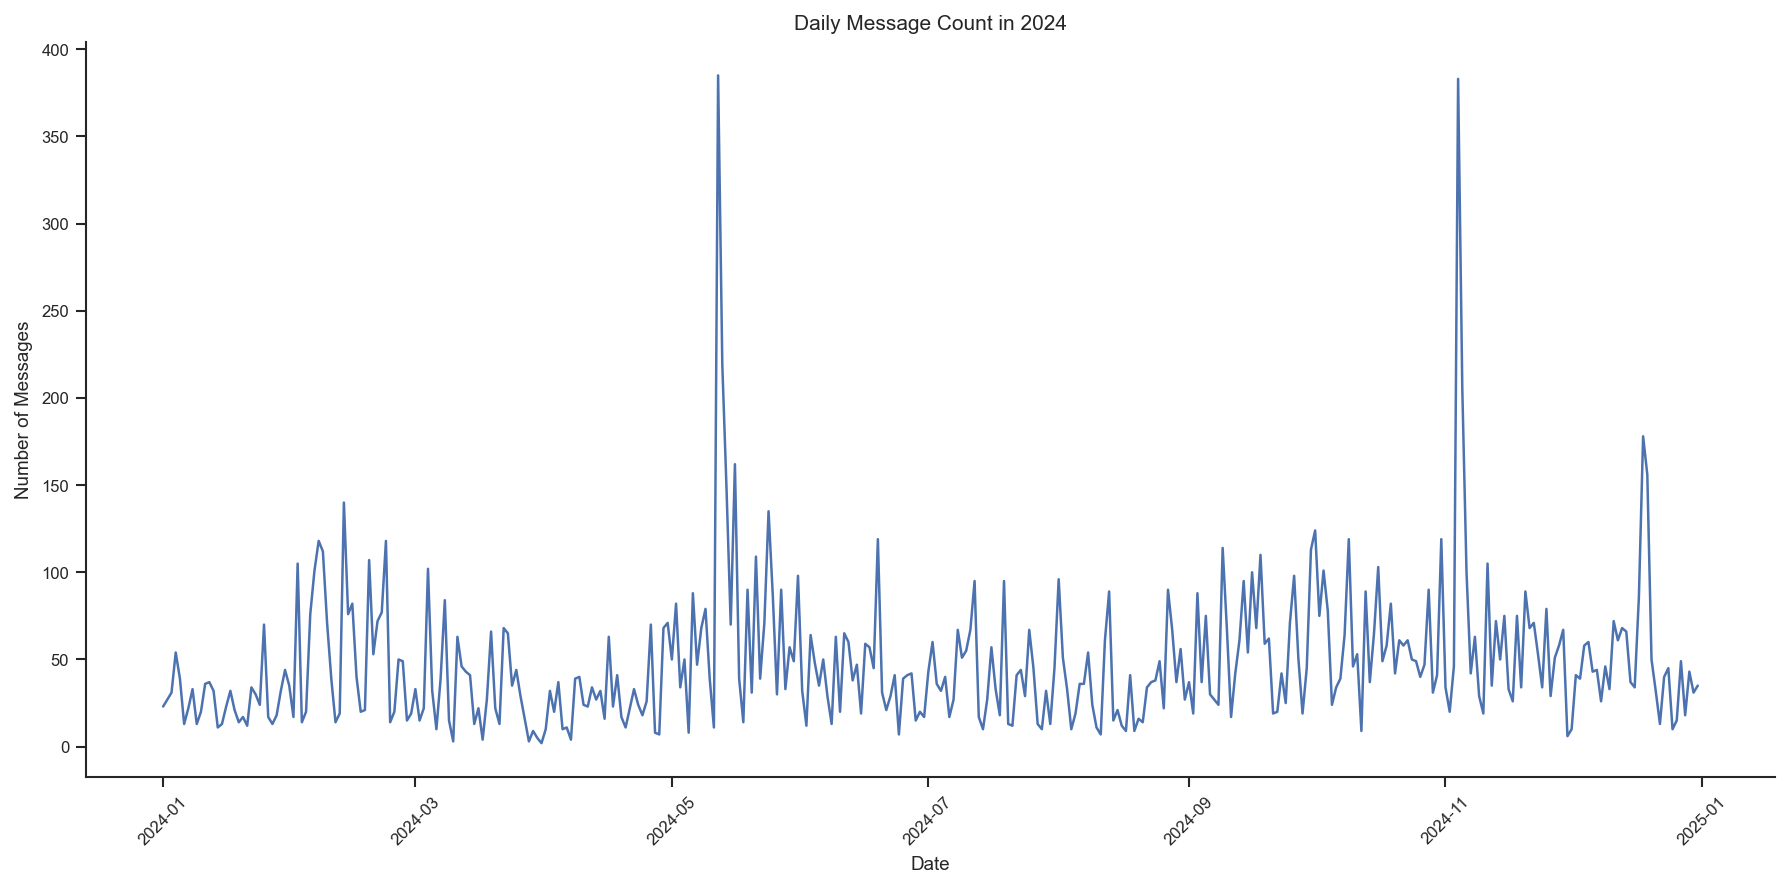

In [46]:
# Create new dataframe with messages from Jan 1st 2024 until Jan 1st 2025
df_2024 = df[(df['date'] >= '2024-01-01') & (df['date'] < '2025-01-01')].copy()
print(f"Total messages from Jan 1st 2024 until Jan 1st 2025: {len(df_2024)}")
print(f"Total messages sent in total (until Nov 10th 2025): {len(df)}")
print(f"Date range: {df_2024['date'].min()} to {df_2024['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_2024['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As it can be seen, the major part of the messages were sent in the first three months after the DANA.

In [47]:
# Calculate waiting times (inter-arrival times) between consecutive messages

# Calculate time differences in seconds
df_2024['waiting_time'] = df_2024['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times = df_2024['waiting_time'].dropna()
waiting_times = waiting_times[waiting_times > 0]

print(f"Number of waiting times: {len(waiting_times)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times.mean():.2f} seconds ({waiting_times.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times.median():.2f} seconds ({waiting_times.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times.min():.2f} seconds")
print(f"  Max: {waiting_times.max():.2f} seconds ({waiting_times.max()/3600:.2f} hours)")

Number of waiting times: 17313
Statistics:
  Mean: 1825.48 seconds (30.42 minutes)
  Median: 235.00 seconds (3.92 minutes)
  Min: 1.00 seconds
  Max: 78874.00 seconds (21.91 hours)


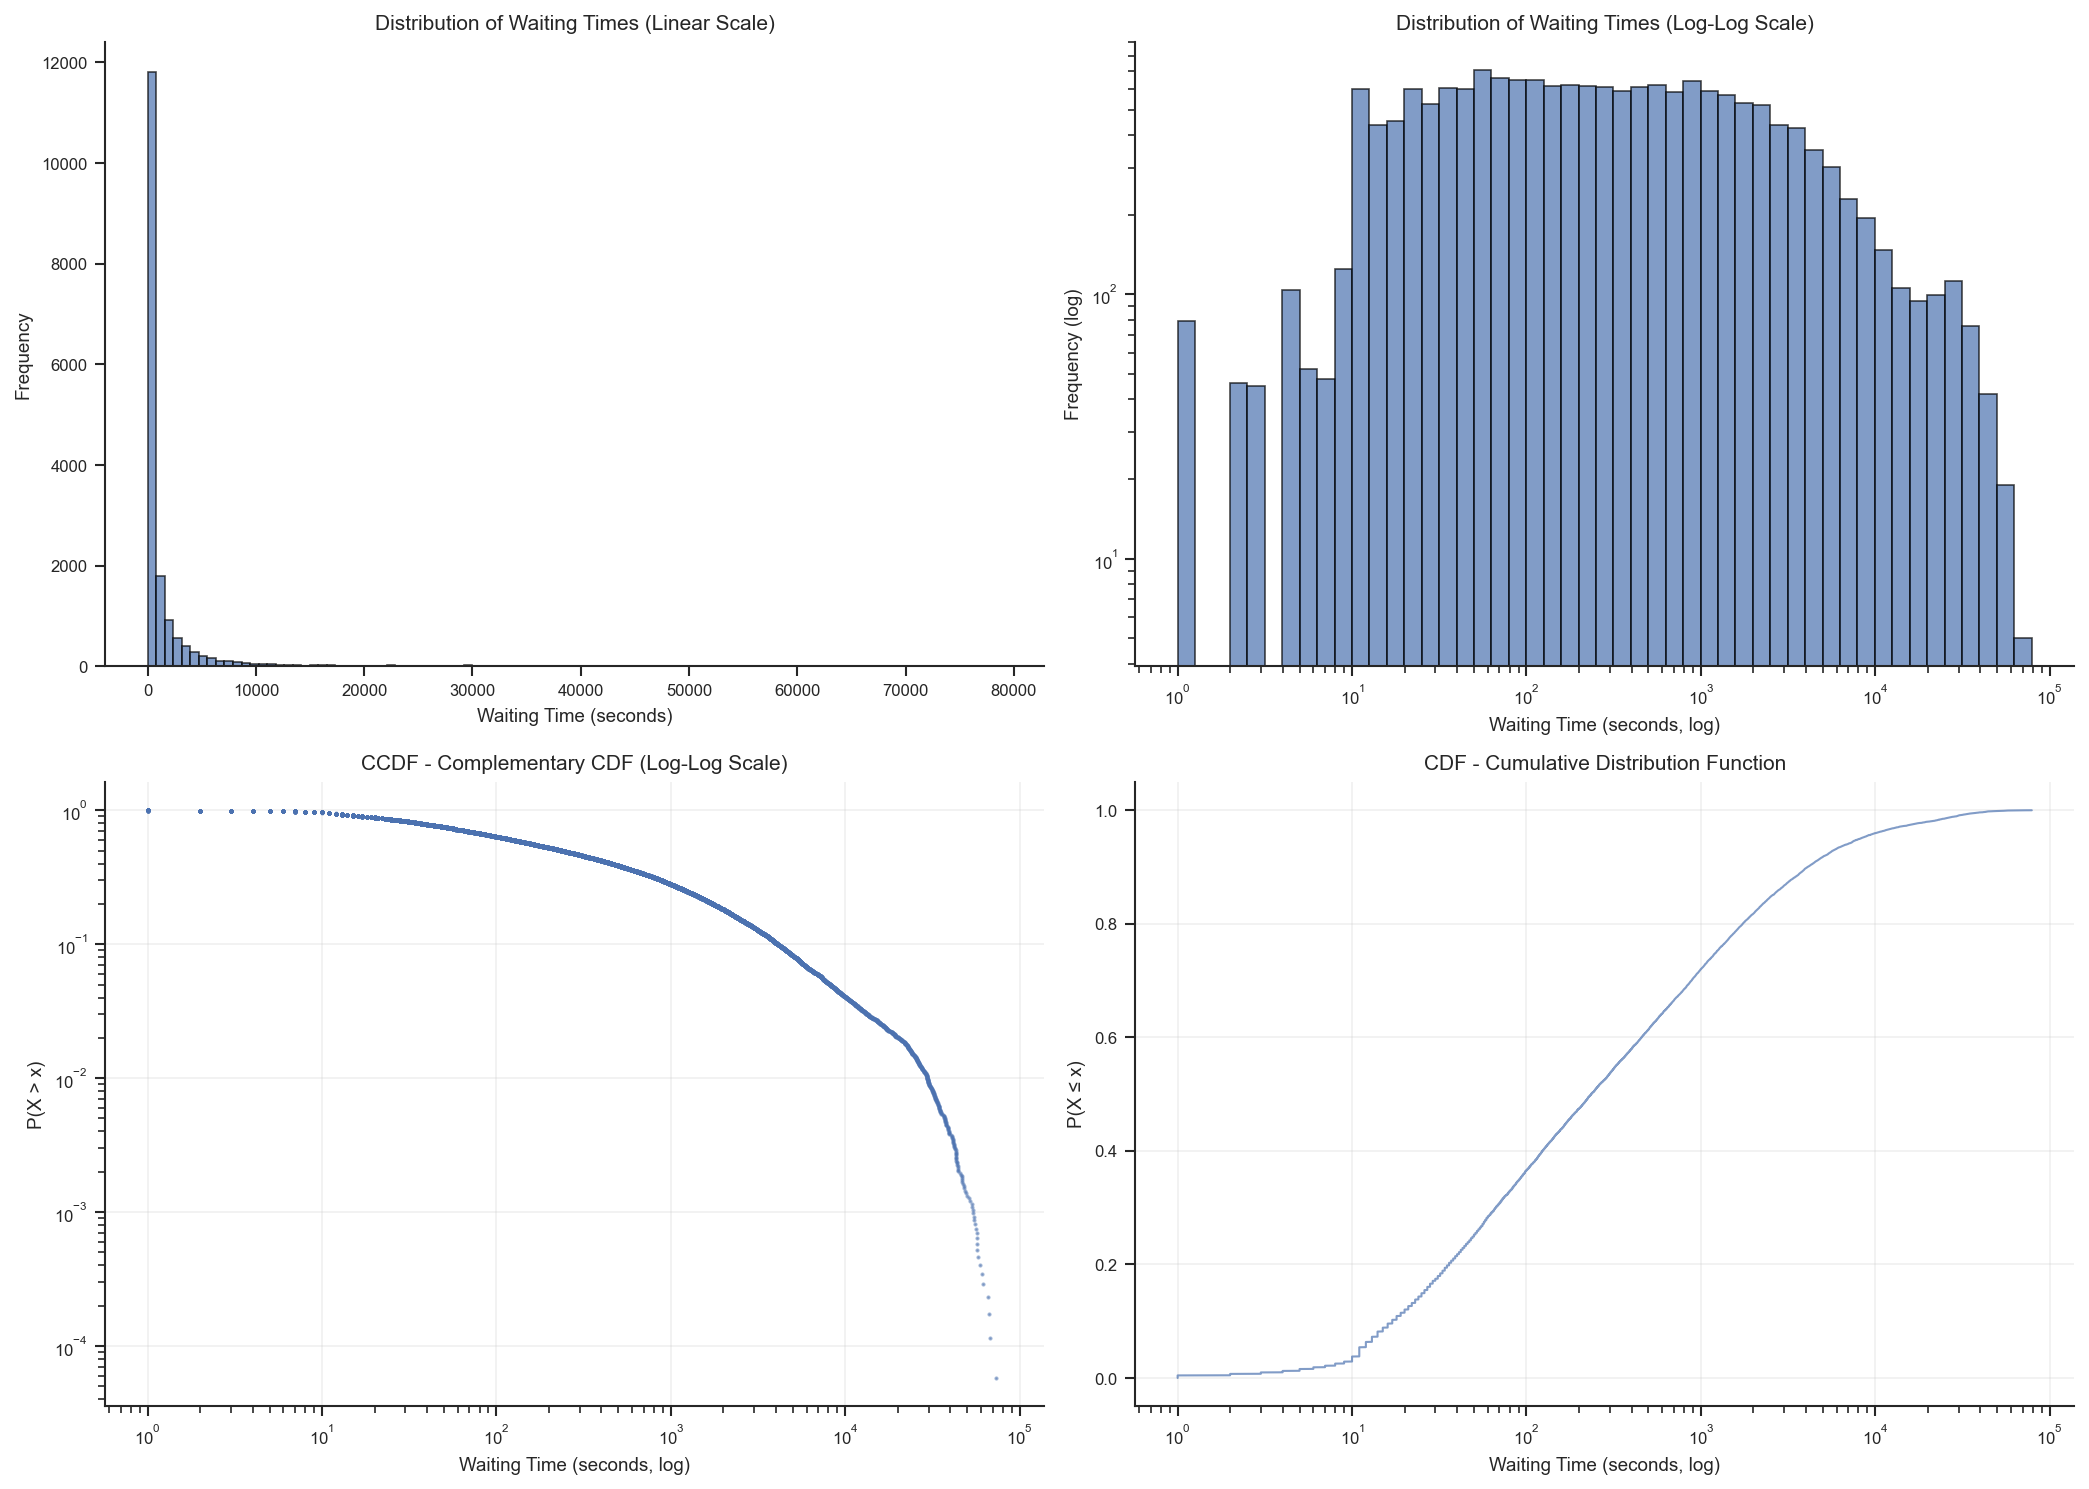

In [48]:
# Visualize the distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times = np.sort(waiting_times)
ccdf = 1 - np.arange(1, len(sorted_times) + 1) / len(sorted_times)
axes[1, 0].plot(sorted_times, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times, np.arange(1, len(sorted_times) + 1) / len(sorted_times), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Fit to truncated power law

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

TRUNCATED POWER LAW FIT RESULTS
alpha: 1.5048
lambda: 0.000030
xmin: 3061.0000
sigma: nan
Data points above xmin: 2268 / 17313 (13.10%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 9.7476, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 10.5755, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 12.0301, p = 0.0000
  ✓ Truncated power law is significantly better

KS distance (truncated power law): 0.0364
✓ Good fit (KS < 0.1)


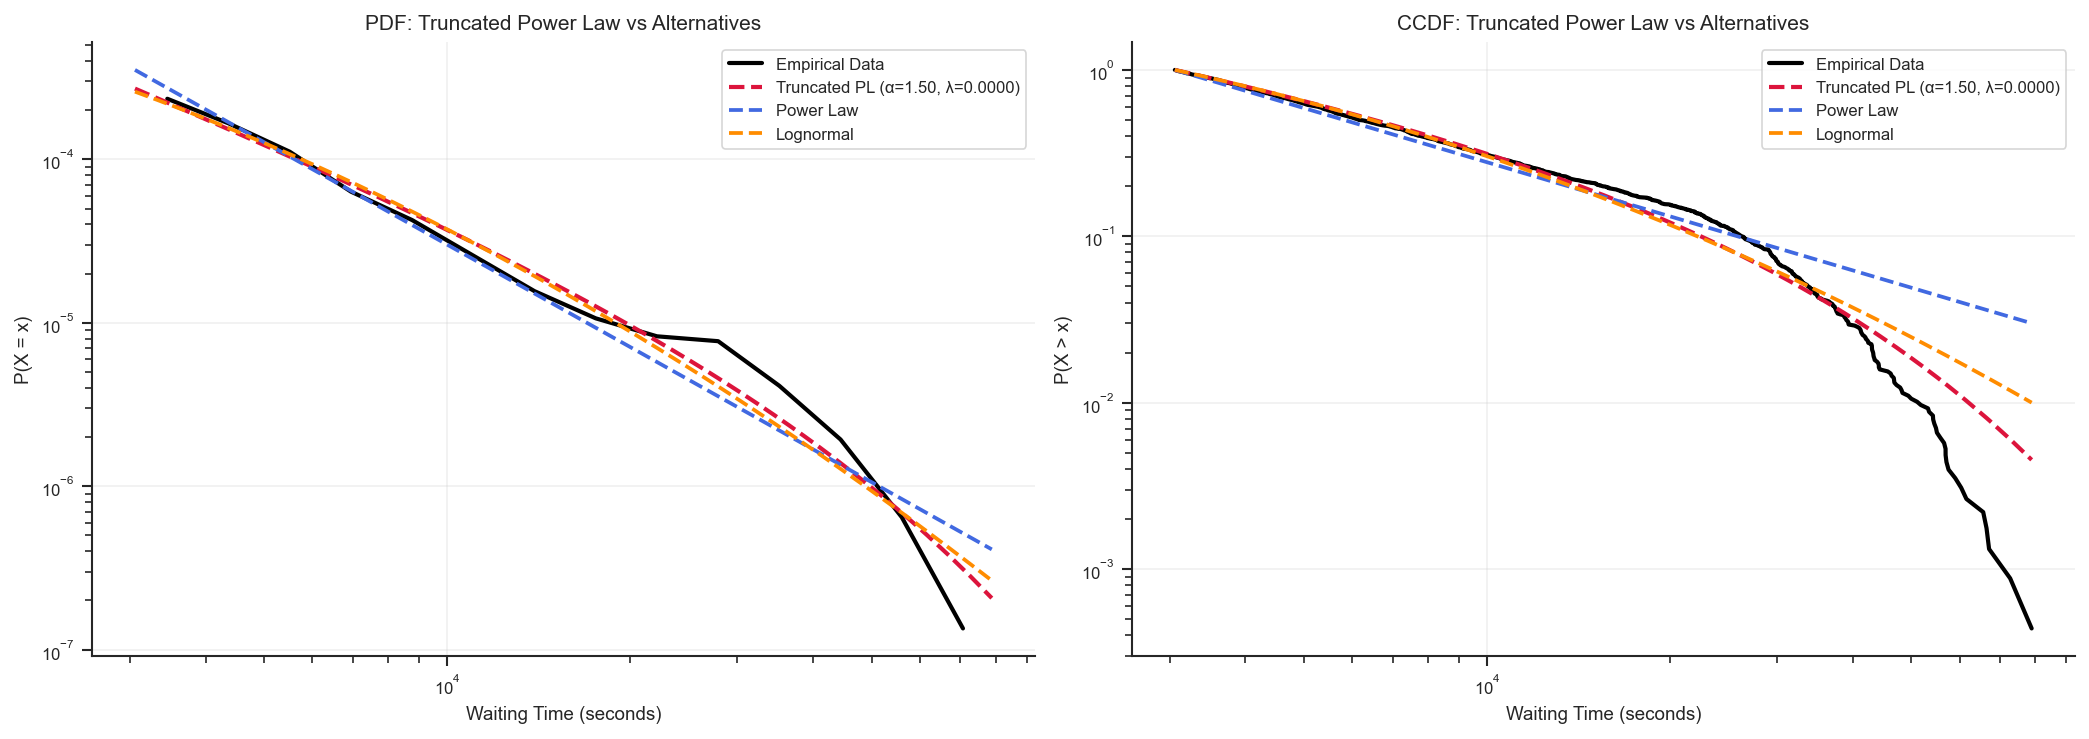

KS statistic (tail): 0.036858
KS p-value (tail): 0.00410827


In [49]:
import powerlaw

# Prepare data
data_tpl = np.asarray(waiting_times.values, dtype=float)
data_tpl = data_tpl[np.isfinite(data_tpl)]
data_tpl = data_tpl[data_tpl > 0]

# Fit using powerlaw package
fit_tpl = powerlaw.Fit(data_tpl, discrete=False, verbose=False)
tpl = fit_tpl.truncated_power_law

alpha_tpl = getattr(tpl, "alpha", np.nan)
lambda_tpl = getattr(tpl, "Lambda", np.nan)
xmin_tpl = getattr(tpl, "xmin", np.nan)
sigma_tpl = getattr(tpl, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl:.4f}")
print(f"lambda: {lambda_tpl:.6f}")
print(f"xmin: {xmin_tpl:.4f}")
print(f"sigma: {sigma_tpl:.4f}")
n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
if len(tail_tpl) == 0:
    ks_tpl = float("nan")
else:
    empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
    try:
        model_cdf_tpl = tpl.cdf(tail_tpl)
    except Exception:
        model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
    ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl:.4f}")
if np.isnan(ks_tpl):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_tpl.plot_pdf(color='black', linewidth=2, label='Empirical Data', ax=axes[0])
tpl.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[0]
 )
fit_tpl.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Waiting Time (seconds)')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law vs Alternatives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fit_tpl.plot_ccdf(color='black', linewidth=2, label='Empirical Data', ax=axes[1])
tpl.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[1]
 )
fit_tpl.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Waiting Time (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF: Truncated Power Law vs Alternatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# One-off: compute KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl:.6f}")
print(f"KS p-value (tail): {ks_p_tpl:.6g}")
print("="*70)

In [50]:
# Bootstrap uncertainty estimates for alpha and lambda (truncated power law)
import numpy as np
import powerlaw

# Reuse cleaned data from previous fit cell if available
if 'data_tpl' not in globals():
    data_tpl = np.asarray(waiting_times.values, dtype=float)
    data_tpl = data_tpl[np.isfinite(data_tpl)]
    data_tpl = data_tpl[data_tpl > 0]

rng = np.random.default_rng(87)
n_boot = 120  # increase to 300+ for tighter CIs (slower)

alpha_boot = []
lambda_boot = []

for _ in range(n_boot):
    sample = rng.choice(data_tpl, size=len(data_tpl), replace=True)
    try:
        fit_b = powerlaw.Fit(sample, discrete=False, verbose=False)
        tpl_b = fit_b.truncated_power_law
        a = float(getattr(tpl_b, 'alpha', np.nan))
        l = float(getattr(tpl_b, 'Lambda', np.nan))
        if np.isfinite(a) and np.isfinite(l):
            alpha_boot.append(a)
            lambda_boot.append(l)
    except Exception:
        continue

alpha_boot = np.asarray(alpha_boot, dtype=float)
lambda_boot = np.asarray(lambda_boot, dtype=float)

if alpha_boot.size < 30 or lambda_boot.size < 30:
    print(f"Too few successful bootstrap fits: alpha={alpha_boot.size}, lambda={lambda_boot.size}")
else:
    alpha_se = np.std(alpha_boot, ddof=1)
    lambda_se = np.std(lambda_boot, ddof=1)

    alpha_ci = np.percentile(alpha_boot, [2.5, 97.5])
    lambda_ci = np.percentile(lambda_boot, [2.5, 97.5])

    print('='*70)
    print('BOOTSTRAP UNCERTAINTY (Truncated Power Law)')
    print('='*70)
    print(f"Successful bootstrap fits: {alpha_boot.size}/{n_boot}")
    print(f"alpha estimate:  {alpha_tpl:.6f} +/- {alpha_se:.6f} (SE)")
    print(f"alpha 95% CI:    [{alpha_ci[0]:.6f}, {alpha_ci[1]:.6f}]")
    print(f"lambda estimate: {lambda_tpl:.8f} +/- {lambda_se:.8f} (SE)")
    print(f"lambda 95% CI:   [{lambda_ci[0]:.8f}, {lambda_ci[1]:.8f}]")
    print('='*70)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

BOOTSTRAP UNCERTAINTY (Truncated Power Law)
Successful bootstrap fits: 120/120
alpha estimate:  1.504785 +/- 0.056072 (SE)
alpha 95% CI:    [1.384263, 1.614373]
lambda estimate: 0.00003018 +/- 0.00000272 (SE)
lambda 95% CI:   [0.00002614, 0.00003615]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


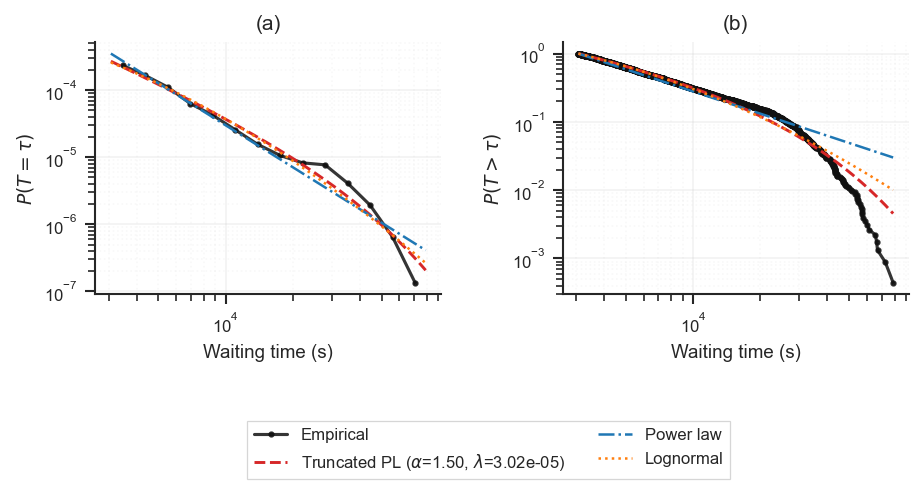

In [51]:
# Paper-ready visualization: Truncated power law vs alternatives
import seaborn as sns
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import matplotlib as mpl

sns.set_theme(style="ticks", context="paper")
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

palette = {
    "empirical": "#111111",
    "tpl": "#D62728",
    "pl": "#1F77B4",
    "ln": "#FF7F0E",
}

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))

# --- PDF panel ---
fit_tpl.plot_pdf(
    color=palette["empirical"], linewidth=1.5, marker='o', markersize=2, alpha=0.85,
    label="Empirical", ax=axes[0]
 )
tpl.plot_pdf(
    color=palette["tpl"], linestyle='--', linewidth=1.4,
    label=rf"Truncated PL ($\alpha$={alpha_tpl:.2f}, $\lambda$={lambda_tpl:.2e})", ax=axes[0]
 )
fit_tpl.power_law.plot_pdf(
    color=palette["pl"], linestyle='-.', linewidth=1.2, label="Power law", ax=axes[0]
 )
fit_tpl.lognormal.plot_pdf(
    color=palette["ln"], linestyle=':', linewidth=1.2, label="Lognormal", ax=axes[0]
 )

#axes[0].set_title("Probability Density Function", pad=6)
axes[0].set_title("(a)", pad=6)
axes[0].set_xlabel("Waiting time (s)")
axes[0].set_ylabel(r"$P(T=τ)$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].xaxis.set_major_locator(LogLocator(base=10))
axes[0].yaxis.set_major_locator(LogLocator(base=10))
axes[0].xaxis.set_major_formatter(LogFormatterMathtext())
axes[0].yaxis.set_major_formatter(LogFormatterMathtext())
axes[0].grid(which="major", alpha=0.25, linestyle='-')
axes[0].grid(which="minor", alpha=0.12, linestyle=':')

# --- CCDF panel ---
fit_tpl.plot_ccdf(
    color=palette["empirical"], linewidth=1.5, marker='o', markersize=2, alpha=0.85,
    label="Empirical", ax=axes[1]
 )
tpl.plot_ccdf(
    color=palette["tpl"], linestyle='--', linewidth=1.4,
    label=rf"Truncated PL ($\alpha$={alpha_tpl:.2f}, $\lambda$={lambda_tpl:.2e})", ax=axes[1]
 )
fit_tpl.power_law.plot_ccdf(
    color=palette["pl"], linestyle='-.', linewidth=1.2, label="Power law", ax=axes[1]
 )
fit_tpl.lognormal.plot_ccdf(
    color=palette["ln"], linestyle=':', linewidth=1.2, label="Lognormal", ax=axes[1]
 )

#axes[1].set_title("Complementary CDF", pad=6)
axes[1].set_title("(b)", pad=6)
axes[1].set_xlabel("Waiting time (s)")
axes[1].set_ylabel(r"$P(T>τ)$")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].xaxis.set_major_locator(LogLocator(base=10))
axes[1].yaxis.set_major_locator(LogLocator(base=10))
axes[1].xaxis.set_major_formatter(LogFormatterMathtext())
axes[1].yaxis.set_major_formatter(LogFormatterMathtext())
axes[1].grid(which="major", alpha=0.25, linestyle='-')
axes[1].grid(which="minor", alpha=0.12, linestyle=':')

# Shared legend below both panels
handles, labels = axes[1].get_legend_handles_labels()
legend = fig.legend(
    handles, labels, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.18),
    frameon=True, fancybox=False, edgecolor="0.8"
 )
legend.get_frame().set_linewidth(0.6)

fig.subplots_adjust(bottom=0.28, wspace=0.35)

fig.savefig("paper_waiting_time_fit_vagarenfe_2024.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Waiting times after Jan 15th 2026

Here we will only consider messages until 2 weeks after the rain on Oct. 29th 2024 (Nov. 12 2024)

Total messages from Jan 15th 2026: 15550
Total messages sent in total: 92813
Date range: 2026-01-15 05:22:16+00:00 to 2026-04-28 15:40:35+00:00


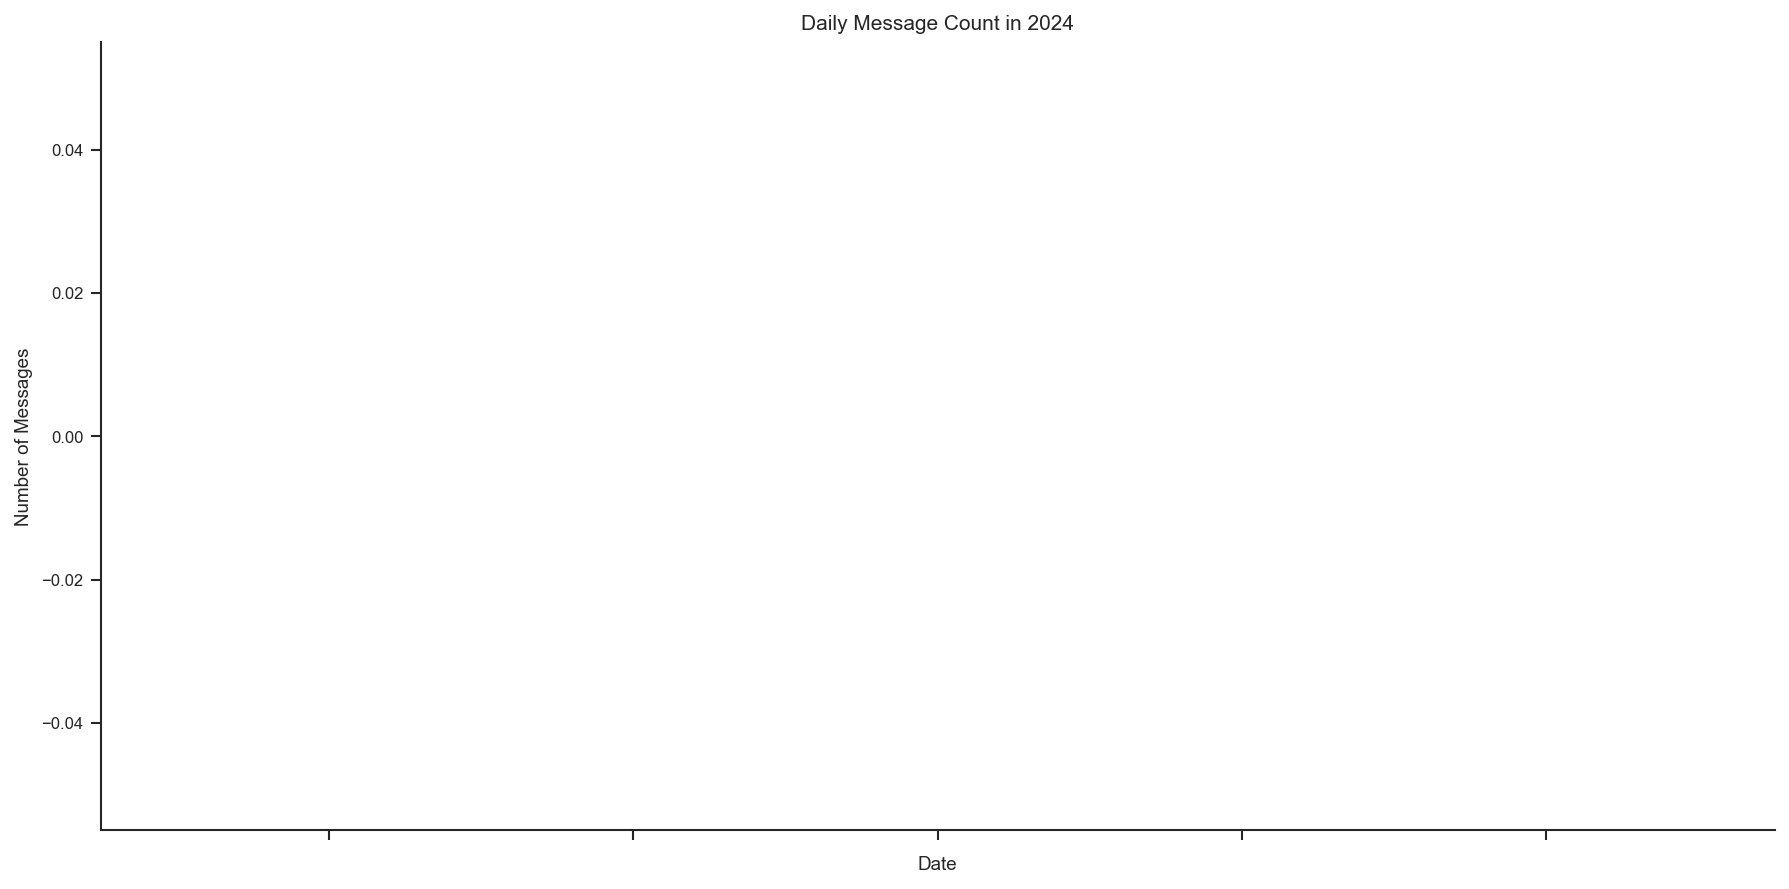

In [52]:
# Create new dataframe with messages after the incidents (Jan. 15th 2026)
df_twoweeks = df[df['date'] >= '2026-01-15'].copy()
print(f"Total messages from Jan 15th 2026: {len(df_twoweeks)}")
print(f"Total messages sent in total: {len(df)}")
print(f"Date range: {df_twoweeks['date'].min()} to {df_twoweeks['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_twoweeks['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
# Calculate time differences in seconds
df_twoweeks['waiting_time'] = df_twoweeks['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times_w = df_twoweeks['waiting_time'].dropna()
waiting_times_w = waiting_times_w[waiting_times_w > 0]

print(f"Number of waiting times: {len(waiting_times_w)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times_w.mean():.2f} seconds ({waiting_times_w.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times_w.median():.2f} seconds ({waiting_times_w.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times_w.min():.2f} seconds")
print(f"  Max: {waiting_times_w.max():.2f} seconds ({waiting_times_w.max()/3600:.2f} hours)")

Number of waiting times: 15357
Statistics:
  Mean: 581.90 seconds (9.70 minutes)
  Median: 82.00 seconds (1.37 minutes)
  Min: 1.00 seconds
  Max: 65093.00 seconds (18.08 hours)


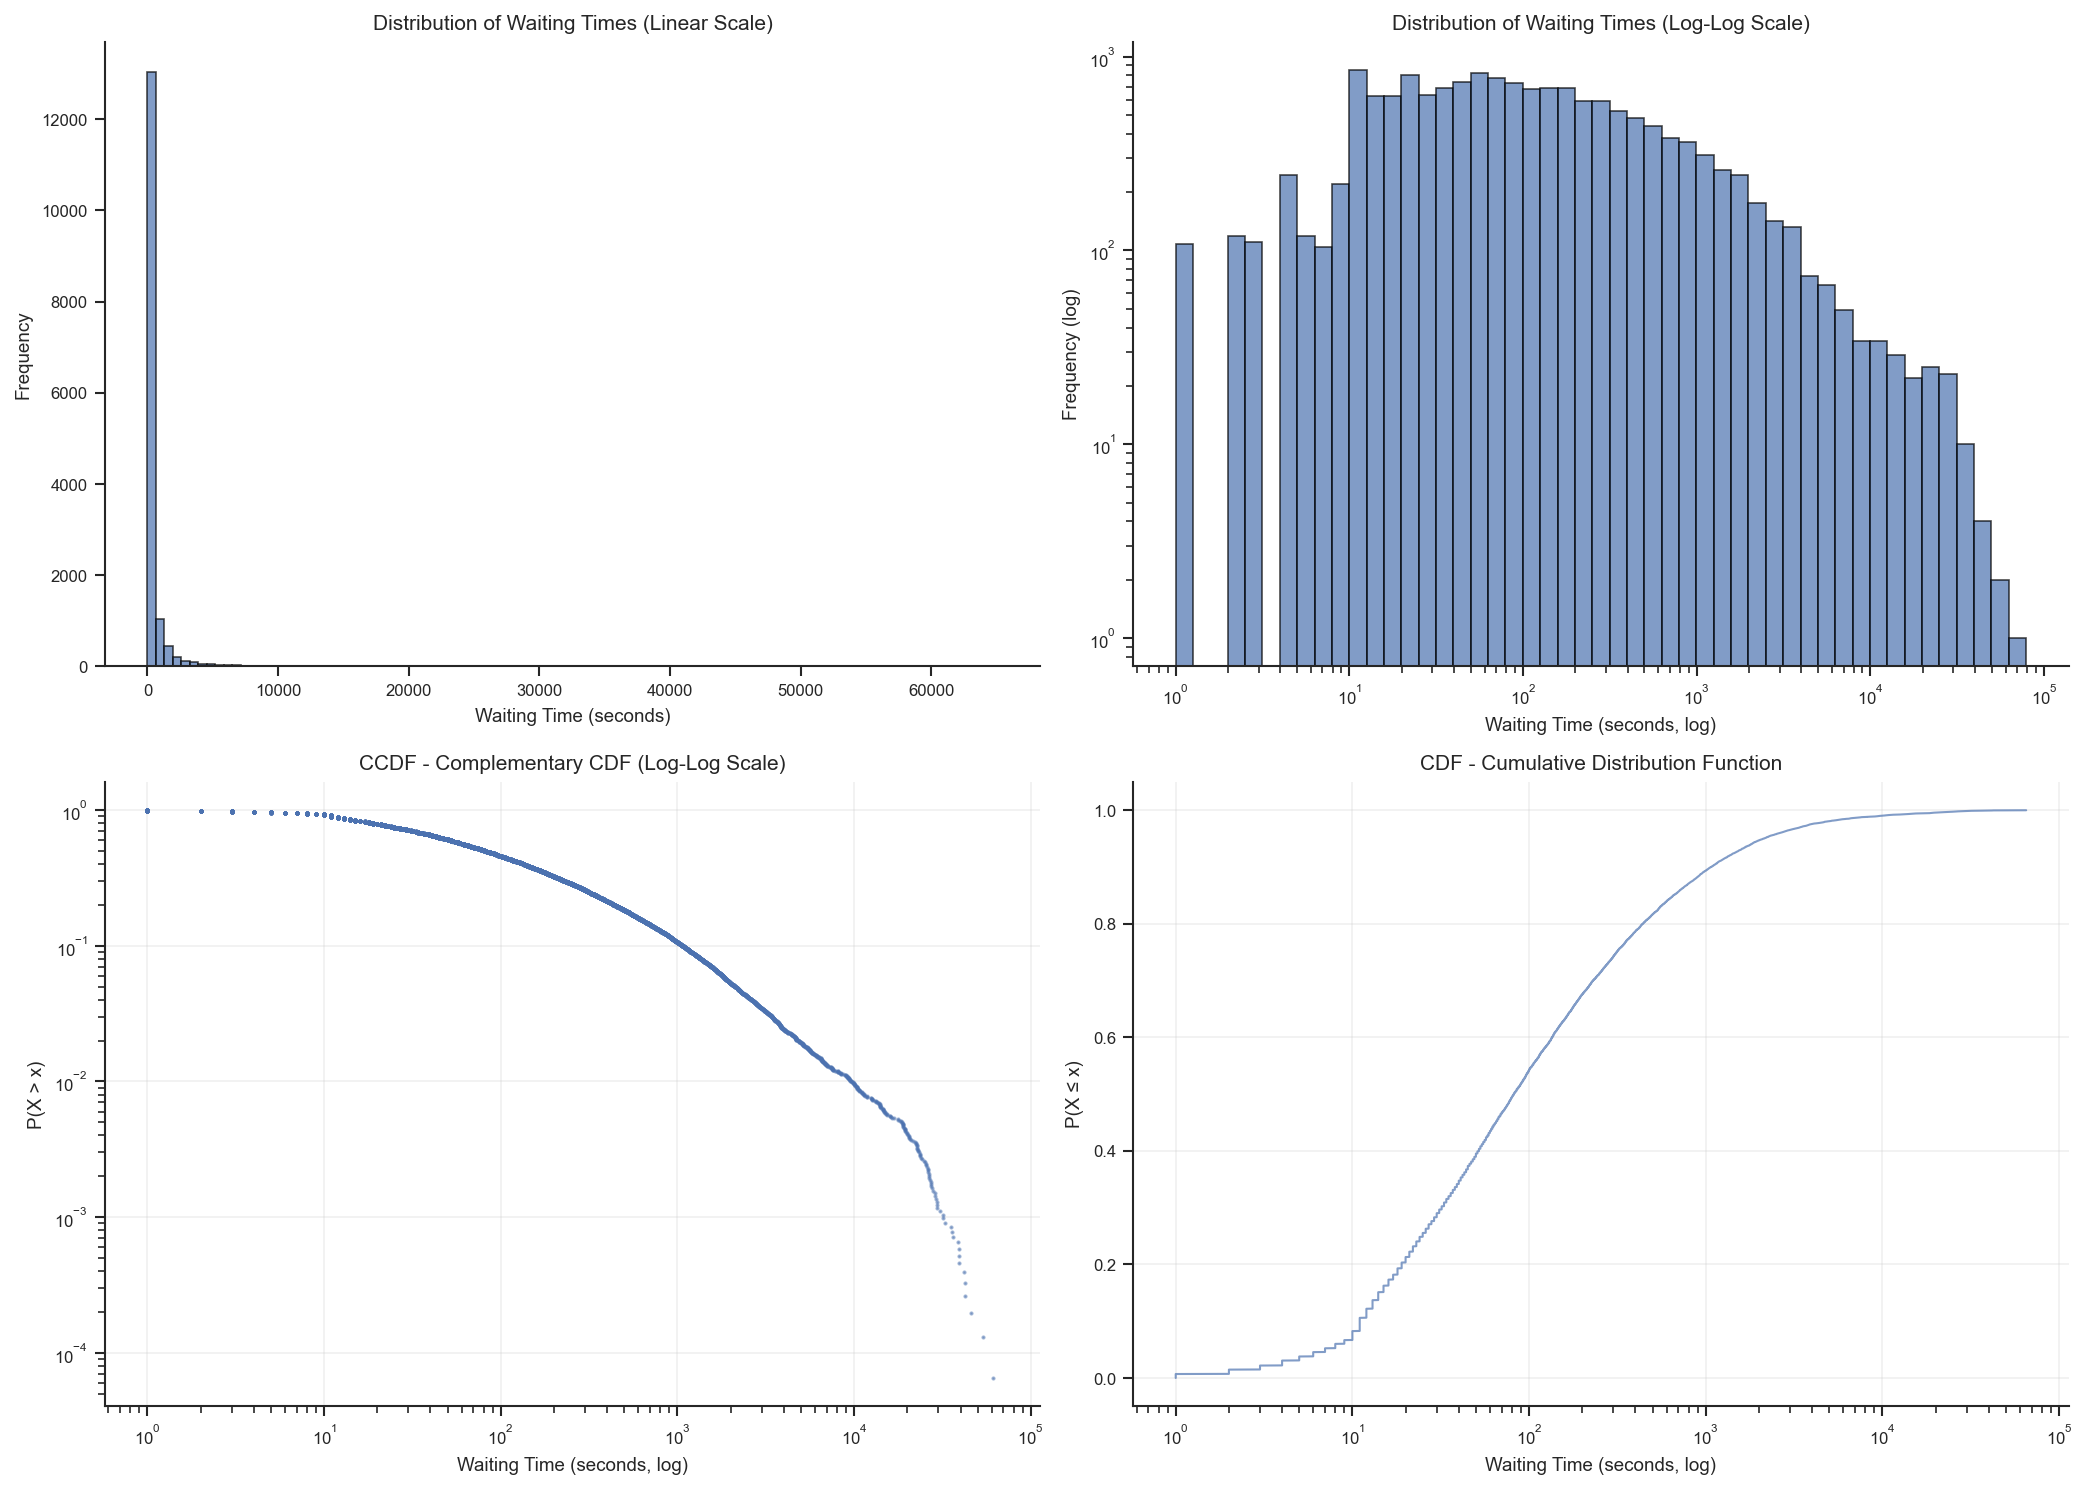

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times_w, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times_w, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times_w = np.sort(waiting_times_w)
ccdf = 1 - np.arange(1, len(sorted_times_w) + 1) / len(sorted_times_w)
axes[1, 0].plot(sorted_times_w, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times_w, np.arange(1, len(sorted_times_w) + 1) / len(sorted_times_w), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Truncated power law fit

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

TRUNCATED POWER LAW FIT RESULTS
alpha: 1.9022
lambda: 0.000020
xmin: 1388.0000
sigma: nan
Data points above xmin: 1212 / 15357 (7.89%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 4.4155, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 5.6041, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 10.9390, p = 0.0000
  ✓ Truncated power law is significantly better

KS distance (truncated power law): 0.0223
✓ Good fit (KS < 0.1)


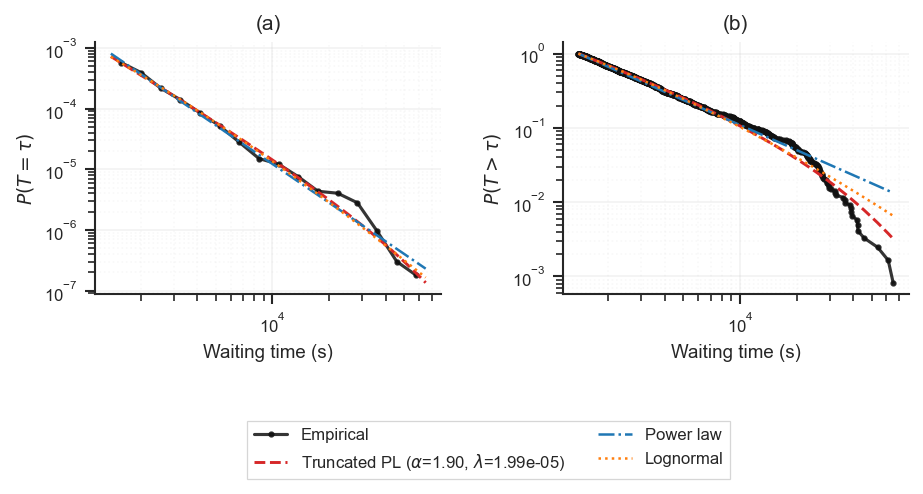

KS statistic (tail): 0.022286
KS p-value (tail): 0.576007


In [55]:
import powerlaw

# Prepare data
data_tpl_w = np.asarray(waiting_times_w.values, dtype=float)
data_tpl_w = data_tpl_w[np.isfinite(data_tpl_w)]
data_tpl_w = data_tpl_w[data_tpl_w > 0]

# Fit using powerlaw package
fit_tpl_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
tpl_w = fit_tpl_w.truncated_power_law

alpha_tpl_w = getattr(tpl_w, "alpha", np.nan)
lambda_tpl_w = getattr(tpl_w, "Lambda", np.nan)
xmin_tpl_w = getattr(tpl_w, "xmin", np.nan)
sigma_tpl_w = getattr(tpl_w, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl_w:.4f}")
print(f"lambda: {lambda_tpl_w:.6f}")
print(f"xmin: {xmin_tpl_w:.4f}")
print(f"sigma: {sigma_tpl_w:.4f}")
n_tail_tpl_w = int(np.sum(data_tpl_w >= xmin_tpl_w))
print(f"Data points above xmin: {n_tail_tpl_w} / {len(data_tpl_w)} ({100 * n_tail_tpl_w / len(data_tpl_w):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl_w.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_tpl_w])
if len(tail_tpl_w) == 0:
    ks_tpl_w = float("nan")
else:
    empirical_cdf_tpl_w = np.arange(1, len(tail_tpl_w) + 1) / len(tail_tpl_w)
    try:
        model_cdf_tpl_w = tpl_w.cdf(tail_tpl_w)
    except Exception:
        model_cdf_tpl_w = 1 - tpl_w.ccdf(tail_tpl_w)
    ks_tpl_w = np.max(np.abs(empirical_cdf_tpl_w - model_cdf_tpl_w))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl_w:.4f}")
if np.isnan(ks_tpl_w):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl_w < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl_w < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Paper-ready visualization
import seaborn as sns
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import matplotlib as mpl

sns.set_theme(style="ticks", context="paper")
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

palette = {
    "empirical": "#111111",
    "tpl": "#D62728",
    "pl": "#1F77B4",
    "ln": "#FF7F0E",
}

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))

# --- PDF panel ---
fit_tpl_w.plot_pdf(
    color=palette["empirical"], linewidth=1.5, marker='o', markersize=2, alpha=0.85,
    label="Empirical", ax=axes[0]
 )
tpl_w.plot_pdf(
    color=palette["tpl"], linestyle='--', linewidth=1.4,
    label=rf"Truncated PL ($\alpha$={alpha_tpl_w:.2f}, $\lambda$={lambda_tpl_w:.2e})", ax=axes[0]
 )
fit_tpl_w.power_law.plot_pdf(
    color=palette["pl"], linestyle='-.', linewidth=1.2, label="Power law", ax=axes[0]
 )
fit_tpl_w.lognormal.plot_pdf(
    color=palette["ln"], linestyle=':', linewidth=1.2, label="Lognormal", ax=axes[0]
 )

#axes[0].set_title("Probability Density Function", pad=6)
axes[0].set_title("(a)", pad=6)
axes[0].set_xlabel("Waiting time (s)")
axes[0].set_ylabel(r"$P(T=τ)$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].xaxis.set_major_locator(LogLocator(base=10))
axes[0].yaxis.set_major_locator(LogLocator(base=10))
axes[0].xaxis.set_major_formatter(LogFormatterMathtext())
axes[0].yaxis.set_major_formatter(LogFormatterMathtext())
axes[0].grid(which="major", alpha=0.25, linestyle='-')
axes[0].grid(which="minor", alpha=0.12, linestyle=':')

# --- CCDF panel ---
fit_tpl_w.plot_ccdf(
    color=palette["empirical"], linewidth=1.5, marker='o', markersize=2, alpha=0.85,
    label="Empirical", ax=axes[1]
 )
tpl_w.plot_ccdf(
    color=palette["tpl"], linestyle='--', linewidth=1.4,
    label=rf"Truncated PL ($\alpha$={alpha_tpl_w:.2f}, $\lambda$={lambda_tpl_w:.2e})", ax=axes[1]
 )
fit_tpl_w.power_law.plot_ccdf(
    color=palette["pl"], linestyle='-.', linewidth=1.2, label="Power law", ax=axes[1]
 )
fit_tpl_w.lognormal.plot_ccdf(
    color=palette["ln"], linestyle=':', linewidth=1.2, label="Lognormal", ax=axes[1]
 )

#axes[1].set_title("Complementary CDF", pad=6)
axes[1].set_title("(b)", pad=6)
axes[1].set_xlabel("Waiting time (s)")
axes[1].set_ylabel(r"$P(T>τ)$")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].xaxis.set_major_locator(LogLocator(base=10))
axes[1].yaxis.set_major_locator(LogLocator(base=10))
axes[1].xaxis.set_major_formatter(LogFormatterMathtext())
axes[1].yaxis.set_major_formatter(LogFormatterMathtext())
axes[1].grid(which="major", alpha=0.25, linestyle='-')
axes[1].grid(which="minor", alpha=0.12, linestyle=':')

# Shared legend below both panels
handles, labels = axes[1].get_legend_handles_labels()
legend = fig.legend(
    handles, labels, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.18),
    frameon=True, fancybox=False, edgecolor="0.8"
 )
legend.get_frame().set_linewidth(0.6)

fig.subplots_adjust(bottom=0.28, wspace=0.35)

fig.savefig("paper_waiting_time_fit_vagarenfe_2026.pdf", format="pdf", bbox_inches="tight")

plt.show()

# KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_tpl_w])
ks_stat_tpl_w, ks_p_tpl_w = stats.kstest(tail_tpl_w, tpl_w.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl_w:.6f}")
print(f"KS p-value (tail): {ks_p_tpl_w:.6g}")
print("="*70)

In [56]:
# Bootstrap uncertainty estimates for alpha and lambda (truncated power law) — 2026 section
import numpy as np
import powerlaw

if 'data_tpl_w' not in globals():
    data_tpl_w = np.asarray(waiting_times_w.values, dtype=float)
    data_tpl_w = data_tpl_w[np.isfinite(data_tpl_w)]
    data_tpl_w = data_tpl_w[data_tpl_w > 0]

rng = np.random.default_rng(87)
n_boot = 120  # increase to 300+ for tighter CIs (slower)

alpha_boot_w = []
lambda_boot_w = []

for _ in range(n_boot):
    sample = rng.choice(data_tpl_w, size=len(data_tpl_w), replace=True)
    try:
        fit_b = powerlaw.Fit(sample, discrete=False, verbose=False)
        tpl_b = fit_b.truncated_power_law
        a = float(getattr(tpl_b, 'alpha', np.nan))
        l = float(getattr(tpl_b, 'Lambda', np.nan))
        if np.isfinite(a) and np.isfinite(l):
            alpha_boot_w.append(a)
            lambda_boot_w.append(l)
    except Exception:
        continue

alpha_boot_w = np.asarray(alpha_boot_w, dtype=float)
lambda_boot_w = np.asarray(lambda_boot_w, dtype=float)

if alpha_boot_w.size < 30 or lambda_boot_w.size < 30:
    print(f'Too few successful bootstrap fits: alpha={alpha_boot_w.size}, lambda={lambda_boot_w.size}')
else:
    alpha_se_w = np.std(alpha_boot_w, ddof=1)
    lambda_se_w = np.std(lambda_boot_w, ddof=1)

    alpha_ci_w = np.percentile(alpha_boot_w, [2.5, 97.5])
    lambda_ci_w = np.percentile(lambda_boot_w, [2.5, 97.5])

    print('='*70)
    print('BOOTSTRAP UNCERTAINTY (Truncated Power Law) — 2026 section')
    print('='*70)
    print(f'Successful bootstrap fits: {alpha_boot_w.size}/{n_boot}')
    print(f'alpha estimate:  {alpha_tpl_w:.6f} +/- {alpha_se_w:.6f} (SE)')
    print(f'alpha 95% CI:    [{alpha_ci_w[0]:.6f}, {alpha_ci_w[1]:.6f}]')
    print(f'lambda estimate: {lambda_tpl_w:.8f} +/- {lambda_se_w:.8f} (SE)')
    print(f'lambda 95% CI:   [{lambda_ci_w[0]:.8f}, {lambda_ci_w[1]:.8f}]')
    print('='*70)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

BOOTSTRAP UNCERTAINTY (Truncated Power Law) — 2026 section
Successful bootstrap fits: 120/120
alpha estimate:  1.902161 +/- 0.058781 (SE)
alpha 95% CI:    [1.808601, 2.015535]
lambda estimate: 0.00001988 +/- 0.00000405 (SE)
lambda 95% CI:   [0.00001385, 0.00002869]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


### Normal power law

In [57]:
# Fit to a power law (without truncation) for comparison
fit_pl_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
alpha_pl_w = getattr(fit_pl_w.power_law, "alpha", np.nan)
xmin_pl_w = getattr(fit_pl_w.power_law, "xmin", np.nan)
print("="*70)
print("POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_pl_w:.4f}")
print(f"xmin: {xmin_pl_w:.4f}")
n_tail_pl_w = int(np.sum(data_tpl_w >= xmin_pl_w))
print(f"Data points above xmin: {n_tail_pl_w} / {len(data_tpl_w)} ({100 * n_tail_pl_w / len(data_tpl_w):.2f}%)")


POWER LAW FIT RESULTS
alpha: 2.1212
xmin: 1388.0000
Data points above xmin: 1212 / 15357 (7.89%)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [58]:
# KS test for power law fit
tail_pl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_pl_w])
ks_stat_pl_w, ks_p_pl_w = stats.kstest(tail_pl_w, fit_pl_w.power_law.cdf)
print("\n" + "="*70)
print(f"KS statistic (power law tail): {ks_stat_pl_w:.6f}")
print(f"KS p-value (power law tail): {ks_p_pl_w:.6g}")
print("="*70)



KS statistic (power law tail): 0.021200
KS p-value (power law tail): 0.639307


### log-normal distribution

In [59]:
# Fit to lognormal for comparison
fit_ln_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
alpha_ln_w = getattr(fit_ln_w.lognormal, "mu", np.nan)
sigma_ln_w = getattr(fit_ln_w.lognormal, "sigma", np.nan)
print("\n" + "="*70)
print("LOGNORMAL FIT RESULTS")
print("="*70)
print(f"mu: {alpha_ln_w:.4f}")
print(f"sigma: {sigma_ln_w:.4f}")
print(f"Data points above lognormal xmin: {len(data_tpl_w)} / {len(data_tpl_w)} (100.00%)")
print("="*70)

# KS test for lognormal fit
tail_ln_w = np.sort(data_tpl_w)
ks_stat_ln_w, ks_p_ln_w = stats.kstest(tail_ln_w, fit_ln_w.lognormal.cdf)
print("\n" + "="*70)
print(f"KS statistic (lognormal): {ks_stat_ln_w:.6f}")
print(f"KS p-value (lognormal): {ks_p_ln_w:.6g}")
print("="*70)


LOGNORMAL FIT RESULTS
mu: 2.6765
sigma: 2.3475
Data points above lognormal xmin: 15357 / 15357 (100.00%)

KS statistic (lognormal): 0.022473
KS p-value (lognormal): 3.60703e-07


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [60]:
# Clauset et al. (2009) semiparametric bootstrap p-value for TPL goodness-of-fit
# Algorithm (Section 4.2 of Clauset et al.):
#   1. Fit TPL -> xmin, alpha, lambda, empirical KS statistic D_emp
#   2. For each bootstrap:
#      a. Draw n_below values below xmin from the empirical data (resample)
#      b. Draw n_tail values above xmin from the fitted TPL (acceptance-rejection)
#      c. Fit TPL to the synthetic dataset -> D_boot
#   3. p = fraction of D_boot >= D_emp
import numpy as np
import powerlaw
from scipy.stats import kstest

def _sample_tpl(n, xmin, alpha, lam, rng, max_rounds=50):
    samples = []
    for _ in range(max_rounds):
        need = n - len(samples)
        if need <= 0:
            break
        u = rng.uniform(size=need * 5)
        t = xmin * u ** (-1.0 / (alpha - 1.0))       # Pareto proposal
        accept = rng.uniform(size=len(t)) < np.exp(-lam * (t - xmin))
        samples.extend(t[accept].tolist())
    return np.array(samples[:n])


def _tpl_ks(data, xmin, alpha, lam):
    tail = data[data >= xmin]
    if len(tail) == 0:
        return np.nan
    def cdf(t):
        s = (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)
        return 1.0 - np.clip(s, 0.0, 1.0)
    return kstest(tail, cdf).statistic


def clauset_tpl_pvalue(data, n_bootstrap=1000, discrete=False, seed=42):
    rng  = np.random.default_rng(seed)
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data) & (data > 0)]

    fit  = powerlaw.Fit(data, discrete=discrete, verbose=False)
    tpl  = fit.truncated_power_law
    xmin  = float(getattr(tpl, 'xmin',   fit.xmin))
    alpha = float(getattr(tpl, 'alpha',   np.nan))
    lam   = float(getattr(tpl, 'Lambda',  np.nan))

    if not all(np.isfinite([xmin, alpha, lam])):
        print("TPL fit on empirical data failed.")
        return np.nan, np.nan

    D_emp   = _tpl_ks(data, xmin, alpha, lam)
    below   = data[data < xmin]
    n_below = len(below)
    n_tail  = int(np.sum(data >= xmin))

    print(f"Empirical: xmin={xmin:.1f}, alpha={alpha:.4f}, lambda={lam:.6f}")
    print(f"  n_tail={n_tail}, n_below={n_below}, D_emp={D_emp:.4f}")
    print(f"  Running {n_bootstrap} bootstrap samples (this may take a minute)...")

    boot_ks = []
    for b in range(n_bootstrap):
        syn_below = rng.choice(below, size=n_below, replace=True) if n_below > 0 else np.array([])
        syn_tail  = _sample_tpl(n_tail, xmin, alpha, lam, rng)
        if len(syn_tail) < n_tail:
            continue
        syn = np.concatenate([syn_below, syn_tail])
        try:
            fb   = powerlaw.Fit(syn, discrete=discrete, verbose=False)
            tb   = fb.truncated_power_law
            xb   = float(getattr(tb, 'xmin',  fb.xmin))
            ab   = float(getattr(tb, 'alpha',  np.nan))
            lb   = float(getattr(tb, 'Lambda', np.nan))
            if all(np.isfinite([xb, ab, lb])):
                D_b = _tpl_ks(syn, xb, ab, lb)
                if np.isfinite(D_b):
                    boot_ks.append(D_b)
        except Exception:
            continue
        if (b + 1) % 200 == 0:
            print(f"  {b+1}/{n_bootstrap} done...")

    boot_ks = np.array(boot_ks)
    p = np.mean(boot_ks >= D_emp)
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '(n.s.)'
    print(f"\nClauset bootstrap p-value: {p:.4f}  {stars}")
    print(f"  ({len(boot_ks)}/{n_bootstrap} successful bootstraps)")
    print(f"  Interpretation: {'TPL is a plausible fit' if p >= 0.1 else 'TPL fit is NOT plausible (p < 0.1)'}")
    return p, D_emp


In [61]:
# Clauset et al. bootstrap p-value — 2024 and 2026 sections
print("=" * 60)
print("SECTION 2024")
print("=" * 60)
p_clauset_2024, D_2024 = clauset_tpl_pvalue(data_tpl, n_bootstrap=1000, discrete=False)

print()
print("=" * 60)
print("SECTION 2026")
print("=" * 60)
p_clauset_2026, D_2026 = clauset_tpl_pvalue(data_tpl_w, n_bootstrap=1000, discrete=False)


SECTION 2024


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Empirical: xmin=3061.0, alpha=1.5048, lambda=0.000030
  n_tail=2268, n_below=15045, D_emp=0.1433
  Running 1000 bootstrap samples (this may take a minute)...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  200/1000 done...


...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  800/1000 done...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  1000/1000 done...

Clauset bootstrap p-value: 0.1340  (n.s.)
  (1000/1000 successful bootstraps)
  Interpretation: TPL is a plausible fit


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
